# Member 8 — Improvement Experiments
**Economic News Article Relevance Classification — NLP Case Study**

> **8a** — try unigram+bigram features (`ngram_range=(1,2)`). Compare to the best baseline and report the change in metrics.
> **8b** — hyperparameter tuning with `GridSearchCV`. Compare to the best baseline and report the change in metrics.

This notebook:
1. Loads Member 1's `train_split.csv` / `test_split.csv` (same data as every other member).
2. Reads the **best baseline** directly from Member 7's `model_comparison_results.csv` so the comparison target is theirs, not a recomputation.
3. **8a:** rebuilds Bag-of-Words with unigrams + bigrams at 40,000 / 5,000 / 1,000 features and re-trains all four classifiers (NB, Logistic Regression, LinearSVC, LinearSVC balanced).
4. **8b:** tunes each classifier + vectorizer jointly with `GridSearchCV` (5-fold stratified CV on the training set only, scored on Relevant-class F1), then evaluates the best pipelines once on the test set.
5. Builds a combined table (baseline vs best 8a vs best 8b) with metric deltas and saves `improvement_results.csv` for Member 9.

Run locally from the repo root: `uv run jupyter lab`.

In [5]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    make_scorer,
)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

FEATURE_SIZES = [40000, 5000, 1000]   # same three settings as Members 2-7
RANDOM_STATE = 42                      # matches the split seed in case_study.ipynb
POS_LABEL = "Relevant"
LABELS = ["Not Relevant", "Relevant"]  # fixed order for every confusion matrix: [[TN, FP], [FN, TP]]

METRIC_COLS = ["Accuracy", "Precision", "Recall", "F1-Score"]
CM_COLS = ["TN", "FP", "FN", "TP"]

## 1. Load the shared train / test split (Member 1)

In [6]:
train_df = pd.read_csv("train_split.csv")
test_df = pd.read_csv("test_split.csv")

train_df["clean_text"] = train_df["clean_text"].fillna("")
test_df["clean_text"] = test_df["clean_text"].fillna("")

X_text_train = train_df["clean_text"]
X_text_test = test_df["clean_text"]
y_train = train_df["label"]
y_test = test_df["label"]

print(f"Training instances: {len(X_text_train)}")
print(f"Testing instances : {len(X_text_test)}")
print("\nTrain label distribution:")
print(y_train.value_counts())
print("\nTest label distribution:")
print(y_test.value_counts())

Training instances: 6400
Testing instances : 1600

Train label distribution:
label
Not Relevant    5264
Relevant        1136
Name: count, dtype: int64

Test label distribution:
label
Not Relevant    1316
Relevant         284
Name: count, dtype: int64


## 2. Best baseline (from Member 7)

Member 7's `model_comparison_results.csv` holds all 12 baseline runs (4 classifiers × 3 feature sizes, unigram `CountVectorizer`).
The best baseline is the row with the highest Relevant-class F1. Reading it from the file (rather than hard-coding) means that if Member 7 revises their pick, re-running this notebook picks up the change.

In [7]:
comparison = pd.read_csv("model_comparison_results.csv")
baseline = comparison.loc[comparison["F1-Score"].idxmax()].copy()

print("Best baseline (highest Relevant-class F1 across all baseline runs):\n")
print(baseline.to_string())

BASELINE_NAME = f"{baseline['Model']} @ {int(baseline['Max Features'])} feats (unigram)"

Best baseline (highest Relevant-class F1 across all baseline runs):

Model           Multinomial Naive Bayes
Max Features                       5000
Accuracy                         0.7031
Precision                        0.3333
Recall                           0.6725
F1-Score                         0.4457
TN                                  934
FP                                  382
FN                                   93
TP                                  191


## 3. Shared helpers

In [8]:
def evaluate(model, X_train, X_test, *, model_name, max_features, experiment, extra=None):
    # Train, predict, and return one result row in the same layout as model_comparison_results.csv
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=LABELS)
    row = {
        "Experiment": experiment,
        "Model": model_name,
        "Max Features": max_features,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0),
        "Recall": recall_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0),
        "TN": cm[0, 0], "FP": cm[0, 1], "FN": cm[1, 0], "TP": cm[1, 1],
    }
    if extra:
        row.update(extra)
    return row


def delta_vs_baseline(rows_df):
    # Add Δ columns (row metric − baseline metric) for the four headline metrics
    out = rows_df.copy()
    for col in METRIC_COLS:
        out[f"Δ {col}"] = out[col] - baseline[col]
    return out


def print_comparison(row, title):
    print("=" * 70)
    print(title)
    print("=" * 70)
    print(f"{'Metric':<12}{'Baseline':>12}{'This run':>12}{'Δ':>10}")
    for col in METRIC_COLS:
        print(f"{col:<12}{baseline[col]:>12.4f}{row[col]:>12.4f}{row[col] - baseline[col]:>+10.4f}")
    print()
    print("Confusion matrix (baseline)      Confusion matrix (this run)")
    print(f"[[{int(baseline['TN']):5d} {int(baseline['FP']):5d}]            [[{int(row['TN']):5d} {int(row['FP']):5d}]")
    print(f" [{int(baseline['FN']):5d} {int(baseline['TP']):5d}]]            [{int(row['FN']):5d} {int(row['TP']):5d}]]")
    print()


def plot_cm(ax, row, title):
    cm = np.array([[row["TN"], row["FP"]], [row["FN"], row["TP"]]], dtype=int)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([0, 1]); ax.set_xticklabels(LABELS, fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(LABELS, fontsize=8)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")


def make_models():
    # Fresh, unfitted instances every call — same settings Members 3/4/5/7 used
    return {
        "Multinomial Naive Bayes": MultinomialNB(),
        "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, solver="liblinear"),
        "LinearSVC": LinearSVC(max_iter=5000),
        "LinearSVC (Balanced)": LinearSVC(class_weight="balanced", max_iter=5000),
    }

---
# 8a — Unigram + bigram features

Every baseline run used single words only (`ngram_range=(1,1)`). Here the vectorizer also keeps adjacent word pairs
(`ngram_range=(1,2)`), so phrases like *interest rates* or *federal reserve* become features of their own.
`max_features` still caps the vocabulary at the N most frequent terms, so unigrams and bigrams compete for the same N slots.

In [9]:
bigram_rows = []
bigram_vocab_report = []
bigram_vectorizers = {}

for max_feat in FEATURE_SIZES:
    vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=max_feat)
    X_train_bi = vectorizer.fit_transform(X_text_train)
    X_test_bi = vectorizer.transform(X_text_test)
    bigram_vectorizers[max_feat] = vectorizer

    feature_names = vectorizer.get_feature_names_out()
    n_bigrams = int(sum(" " in f for f in feature_names))
    bigram_vocab_report.append({
        "Max Features": max_feat,
        "Vocabulary Size": len(feature_names),
        "Unigrams": len(feature_names) - n_bigrams,
        "Bigrams": n_bigrams,
        "Bigram %": 100 * n_bigrams / len(feature_names),
        "Train Shape": X_train_bi.shape,
        "Test Shape": X_test_bi.shape,
        "Train Sparsity %": 100 * (1 - X_train_bi.nnz / (X_train_bi.shape[0] * X_train_bi.shape[1])),
    })

    print("=" * 70)
    print(f"ngram_range=(1,2)  max_features={max_feat}")
    print("=" * 70)
    print(f"Vocabulary : {len(feature_names)}  ({n_bigrams} bigrams, {100 * n_bigrams / len(feature_names):.1f}%)")
    print(f"Train shape: {X_train_bi.shape}   Test shape: {X_test_bi.shape}")

    for model_name, model in make_models().items():
        row = evaluate(model, X_train_bi, X_test_bi,
                       model_name=model_name, max_features=max_feat,
                       experiment="8a: unigram+bigram")
        bigram_rows.append(row)
        print(f"  {model_name:<26} Acc {row['Accuracy']:.4f}  P {row['Precision']:.4f}  "
              f"R {row['Recall']:.4f}  F1 {row['F1-Score']:.4f}   CM [[{row['TN']} {row['FP']}] [{row['FN']} {row['TP']}]]")
    print()

bigram_vocab_df = pd.DataFrame(bigram_vocab_report)
bigram_results = pd.DataFrame(bigram_rows)

ngram_range=(1,2)  max_features=40000
Vocabulary : 40000  (24644 bigrams, 61.6%)
Train shape: (6400, 40000)   Test shape: (1600, 40000)
  Multinomial Naive Bayes    Acc 0.7512  P 0.3656  R 0.5458  F1 0.4379   CM [[1047 269] [129 155]]
  Logistic Regression        Acc 0.7944  P 0.3743  R 0.2359  F1 0.2894   CM [[1204 112] [217 67]]
  LinearSVC                  Acc 0.7775  P 0.3462  R 0.2852  F1 0.3127   CM [[1163 153] [203 81]]
  LinearSVC (Balanced)       Acc 0.7750  P 0.3417  R 0.2887  F1 0.3130   CM [[1158 158] [202 82]]

ngram_range=(1,2)  max_features=5000
Vocabulary : 5000  (1039 bigrams, 20.8%)
Train shape: (6400, 5000)   Test shape: (1600, 5000)
  Multinomial Naive Bayes    Acc 0.7081  P 0.3357  R 0.6585  F1 0.4447   CM [[946 370] [97 187]]
  Logistic Regression        Acc 0.7638  P 0.3259  R 0.3099  F1 0.3177   CM [[1134 182] [196 88]]
  LinearSVC                  Acc 0.7306  P 0.2882  R 0.3521  F1 0.3170   CM [[1069 247] [184 100]]
  LinearSVC (Balanced)       Acc 0.7294  P 0.

### 8a.1 How the representation changes

In [10]:
display(bigram_vocab_df.round(2))

print("\nUnigram-only baseline representation (Member 2, feature_extraction_summary.csv):")
display(pd.read_csv("feature_extraction_summary.csv"))

,Max Features,Vocabulary Size,Unigrams,Bigrams,Bigram %,Train Shape,Test Shape,Train Sparsity %
0,40000,40000,15356,24644,61.61,"(6400, 40000)","(1600, 40000)",99.70
1,5000,5000,3961,1039,20.78,"(6400, 5000)","(1600, 5000)",98.30
2,1000,1000,932,68,6.80,"(6400, 1000)","(1600, 1000)",94.63



Unigram-only baseline representation (Member 2, feature_extraction_summary.csv):


,max_features_setting,actual_vocab_size,train_matrix_shape,test_matrix_shape,train_sparsity_pct,train_nonzero_entries
0,40000,40000,"(6400, 40000)","(1600, 40000)",99.77,600241
1,5000,5000,"(6400, 5000)","(1600, 5000)",98.43,502470
2,1000,1000,"(6400, 1000)","(1600, 1000)",94.80,332525


### 8a.2 Results at every feature size, all four classifiers

In [11]:
bigram_table = bigram_results[["Model", "Max Features"] + METRIC_COLS + CM_COLS]
display(bigram_table.round(4))

,Model,Max Features,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP
0,Multinomial Naive Bayes,40000,0.7512,0.3656,0.5458,0.4379,1047,269,129,155
1,Logistic Regression,40000,0.7944,0.3743,0.2359,0.2894,1204,112,217,67
2,LinearSVC,40000,0.7775,0.3462,0.2852,0.3127,1163,153,203,81
3,LinearSVC (Balanced),40000,0.7750,0.3417,0.2887,0.3130,1158,158,202,82
4,Multinomial Naive Bayes,5000,0.7081,0.3357,0.6585,0.4447,946,370,97,187
5,Logistic Regression,5000,0.7638,0.3259,0.3099,0.3177,1134,182,196,88
6,LinearSVC,5000,0.7306,0.2882,0.3521,0.3170,1069,247,184,100
7,LinearSVC (Balanced),5000,0.7294,0.2913,0.3662,0.3245,1063,253,180,104
8,Multinomial Naive Bayes,1000,0.7038,0.3241,0.6162,0.4248,951,365,109,175
9,Logistic Regression,1000,0.7938,0.3693,0.2289,0.2826,1205,111,219,65


### 8a.3 Bigram run vs the unigram baseline, per model and feature size

In [12]:
# Same model + same max_features, unigram (Member 7) vs unigram+bigram (this notebook)
uni = comparison[["Model", "Max Features"] + METRIC_COLS].rename(columns={c: f"{c} (uni)" for c in METRIC_COLS})
bi = bigram_results[["Model", "Max Features"] + METRIC_COLS].rename(columns={c: f"{c} (uni+bi)" for c in METRIC_COLS})
paired = uni.merge(bi, on=["Model", "Max Features"])
for col in METRIC_COLS:
    paired[f"Δ {col}"] = paired[f"{col} (uni+bi)"] - paired[f"{col} (uni)"]

paired = paired.sort_values(["Model", "Max Features"], ascending=[True, False]).reset_index(drop=True)
display(paired[["Model", "Max Features"] + [f"Δ {c}" for c in METRIC_COLS]].round(4))

,Model,Max Features,Δ Accuracy,Δ Precision,Δ Recall,Δ F1-Score
0,LinearSVC,40000,0.0231,0.0309,-0.0423,-0.0085
1,LinearSVC,5000,-0.0056,-0.0135,-0.0176,-0.0153
2,LinearSVC,1000,0.0025,0.0138,0.0106,0.0121
3,LinearSVC (Balanced),40000,0.0225,0.0284,-0.0423,-0.0089
4,LinearSVC (Balanced),5000,-0.0031,-0.0076,-0.0106,-0.0088
5,LinearSVC (Balanced),1000,0.0106,0.0077,-0.0070,0.0046
6,Logistic Regression,40000,0.0094,0.0158,-0.0317,-0.0171
7,Logistic Regression,5000,-0.0106,-0.0243,-0.0070,-0.0150
8,Logistic Regression,1000,0.0025,0.0113,0.0071,0.0087
9,Multinomial Naive Bayes,40000,-0.0157,-0.0125,0.0599,0.0126


### 8a.4 Best bigram configuration vs the best baseline

8a best: Multinomial Naive Bayes @ 5000 feats (uni+bi)
vs baseline: Multinomial Naive Bayes @ 5000 feats (unigram)
Metric          Baseline    This run         Δ
Accuracy          0.7031      0.7081   +0.0050
Precision         0.3333      0.3357   +0.0024
Recall            0.6725      0.6585   -0.0140
F1-Score          0.4457      0.4447   -0.0010

Confusion matrix (baseline)      Confusion matrix (this run)
[[  934   382]            [[  946   370]
 [   93   191]]            [   97   187]]



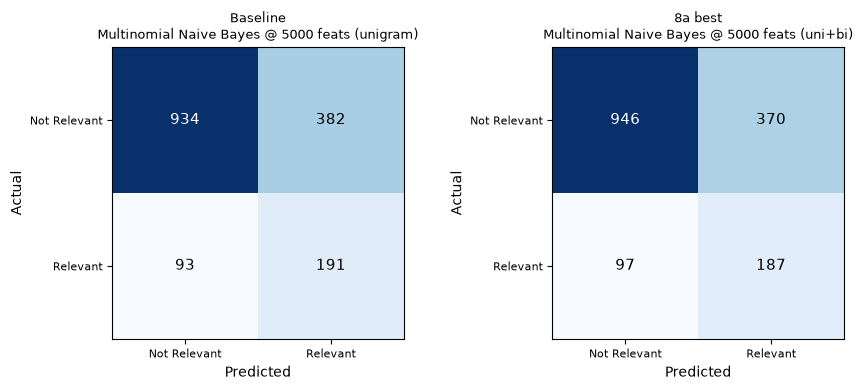

In [13]:
best_8a = bigram_results.loc[bigram_results["F1-Score"].idxmax()]
BEST_8A_NAME = f"{best_8a['Model']} @ {int(best_8a['Max Features'])} feats (uni+bi)"

print_comparison(best_8a, f"8a best: {BEST_8A_NAME}\nvs baseline: {BASELINE_NAME}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_cm(axes[0], baseline, f"Baseline\n{BASELINE_NAME}")
plot_cm(axes[1], best_8a, f"8a best\n{BEST_8A_NAME}")
plt.tight_layout()
plt.show()

### 8a.5 Which bigrams matter?

For Multinomial NB, `feature_log_prob_[Relevant] − feature_log_prob_[Not Relevant]` is the log-odds each feature contributes toward "Relevant".
Listing the top bigrams by this score shows what the extra features actually capture.

In [14]:
vec_40k = bigram_vectorizers[40000]
nb_40k = MultinomialNB().fit(vec_40k.transform(X_text_train), y_train)

classes = list(nb_40k.classes_)
log_odds = nb_40k.feature_log_prob_[classes.index("Relevant")] - nb_40k.feature_log_prob_[classes.index("Not Relevant")]
feature_names = vec_40k.get_feature_names_out()
is_bigram = np.array([" " in f for f in feature_names])

top_rel = pd.DataFrame({
    "bigram": feature_names[is_bigram],
    "log_odds_relevant": log_odds[is_bigram],
}).sort_values("log_odds_relevant", ascending=False)

print("Top 15 bigrams pushing toward 'Relevant':")
display(top_rel.head(15).reset_index(drop=True).round(3))
print("\nTop 15 bigrams pushing toward 'Not Relevant':")
display(top_rel.tail(15).iloc[::-1].reset_index(drop=True).round(3))

Top 15 bigrams pushing toward 'Relevant':


,bigram,log_odds_relevant
0,slow recovery,3.419
1,spending fell,3.285
2,city debt,3.131
3,week fifth,3.131
4,economy picking,3.131
5,mortgages climbed,3.131
6,canadian million,3.131
7,death row,3.131
8,fresh signs,3.131
9,spending retailers,3.131



Top 15 bigrams pushing toward 'Not Relevant':


,bigram,log_odds_relevant
0,hong kong,-2.216
1,insurance corp,-2.028
2,civil service,-1.957
3,postal service,-1.919
4,monetary fund,-1.893
5,securities firms,-1.880
6,mr ford,-1.880
7,metropolitan washington,-1.880
8,dc council,-1.796
9,annual report,-1.796


---
# 8b — Hyperparameter tuning with `GridSearchCV`

Rules followed here so the result is honest:
- The vectorizer and the classifier are tuned **together** inside a `Pipeline`, so the vectorizer is re-fit on each CV fold's training portion (no leakage from validation folds).
- Cross-validation runs on the **training set only** (`StratifiedKFold`, 5 folds, seed 42). The test set is touched exactly once per model, at the end.
- Scoring is **F1 on the Relevant class** — the metric Member 7 used to choose the baseline — not accuracy.

Each classifier gets its own grid. `class_weight` is a grid parameter for Logistic Regression and LinearSVC, so "balanced" vs plain is decided by CV rather than fixed up front.

In [15]:
f1_relevant = make_scorer(f1_score, pos_label=POS_LABEL, zero_division=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

vectorizer_grid = {
    "vec__max_features": [5000, 20000, 40000],
    "vec__ngram_range": [(1, 1), (1, 2)],
}

search_specs = {
    "Multinomial Naive Bayes": (
        MultinomialNB(),
        {**vectorizer_grid, "clf__alpha": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]},
    ),
    "Logistic Regression": (
        LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, solver="liblinear"),
        {**vectorizer_grid, "clf__C": [0.01, 0.1, 1.0, 10.0], "clf__class_weight": [None, "balanced"]},
    ),
    "LinearSVC": (
        LinearSVC(max_iter=5000),
        {**vectorizer_grid, "clf__C": [0.01, 0.1, 1.0], "clf__class_weight": [None, "balanced"]},
    ),
}

for name, (_, grid) in search_specs.items():
    n = int(np.prod([len(v) for v in grid.values()]))
    print(f"{name:<26} {n:3d} candidates × {cv.get_n_splits()} folds = {n * cv.get_n_splits()} fits")

Multinomial Naive Bayes     36 candidates × 5 folds = 180 fits
Logistic Regression         48 candidates × 5 folds = 240 fits
LinearSVC                   36 candidates × 5 folds = 180 fits


In [16]:
searches = {}
grid_rows = []

for model_name, (clf, grid) in search_specs.items():
    pipe = Pipeline([("vec", CountVectorizer()), ("clf", clf)])
    search = GridSearchCV(pipe, grid, scoring=f1_relevant, cv=cv, n_jobs=-1, refit=True, verbose=0)

    t0 = time.time()
    search.fit(X_text_train, y_train)
    elapsed = time.time() - t0
    searches[model_name] = search

    best_params = {k.replace("clf__", "").replace("vec__", ""): v for k, v in search.best_params_.items()}
    print("=" * 70)
    print(f"{model_name}   ({elapsed:.0f}s)")
    print("=" * 70)
    print(f"Best CV F1 (Relevant): {search.best_score_:.4f}")
    print(f"Best params          : {best_params}")

    # Single evaluation on the held-out test set with the refit best pipeline
    best_pipe = search.best_estimator_
    y_pred = best_pipe.predict(X_text_test)
    cm = confusion_matrix(y_test, y_pred, labels=LABELS)

    # Report the tuned model under the name Member 7 used, so balanced SVC still shows up as its own row label
    display_name = model_name
    if model_name == "LinearSVC" and best_params.get("class_weight") == "balanced":
        display_name = "LinearSVC (Balanced)"

    row = {
        "Experiment": "8b: GridSearchCV",
        "Model": display_name,
        "Max Features": best_params["max_features"],
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0),
        "Recall": recall_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0),
        "TN": cm[0, 0], "FP": cm[0, 1], "FN": cm[1, 0], "TP": cm[1, 1],
        "CV F1": search.best_score_,
        "Best Params": str(best_params),
    }
    grid_rows.append(row)
    print(f"Test: Acc {row['Accuracy']:.4f}  P {row['Precision']:.4f}  R {row['Recall']:.4f}  F1 {row['F1-Score']:.4f}")
    print(f"CM  : [[{row['TN']} {row['FP']}] [{row['FN']} {row['TP']}]]\n")

grid_results = pd.DataFrame(grid_rows)

Multinomial Naive Bayes   (35s)
Best CV F1 (Relevant): 0.4426
Best params          : {'alpha': 1.0, 'max_features': 20000, 'ngram_range': (1, 2)}
Test: Acc 0.7219  P 0.3400  R 0.6021  F1 0.4346
CM  : [[984 332] [113 171]]

Logistic Regression   (51s)
Best CV F1 (Relevant): 0.4331
Best params          : {'C': 0.01, 'class_weight': 'balanced', 'max_features': 40000, 'ngram_range': (1, 1)}
Test: Acc 0.7444  P 0.3602  R 0.5669  F1 0.4405
CM  : [[1030 286] [123 161]]

LinearSVC   (82s)
Best CV F1 (Relevant): 0.3764
Best params          : {'C': 0.01, 'class_weight': 'balanced', 'max_features': 20000, 'ngram_range': (1, 1)}
Test: Acc 0.7506  P 0.3442  R 0.4472  F1 0.3890
CM  : [[1074 242] [157 127]]



### 8b.1 Tuned models on the test set (CV score shown next to test score)

In [17]:
display(grid_results[["Model", "Max Features", "Best Params", "CV F1"] + METRIC_COLS + CM_COLS].round(4))

,Model,Max Features,Best Params,CV F1,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP
0,Multinomial Naive Bayes,20000,"{'alpha': 1.0, 'max_features': 20000, 'ngram_r...",0.4426,0.7219,0.3400,0.6021,0.4346,984,332,113,171
1,Logistic Regression,40000,"{'C': 0.01, 'class_weight': 'balanced', 'max_f...",0.4331,0.7444,0.3602,0.5669,0.4405,1030,286,123,161
2,LinearSVC (Balanced),20000,"{'C': 0.01, 'class_weight': 'balanced', 'max_f...",0.3764,0.7506,0.3442,0.4472,0.3890,1074,242,157,127


### 8b.2 What the grid found — CV F1 across the search space

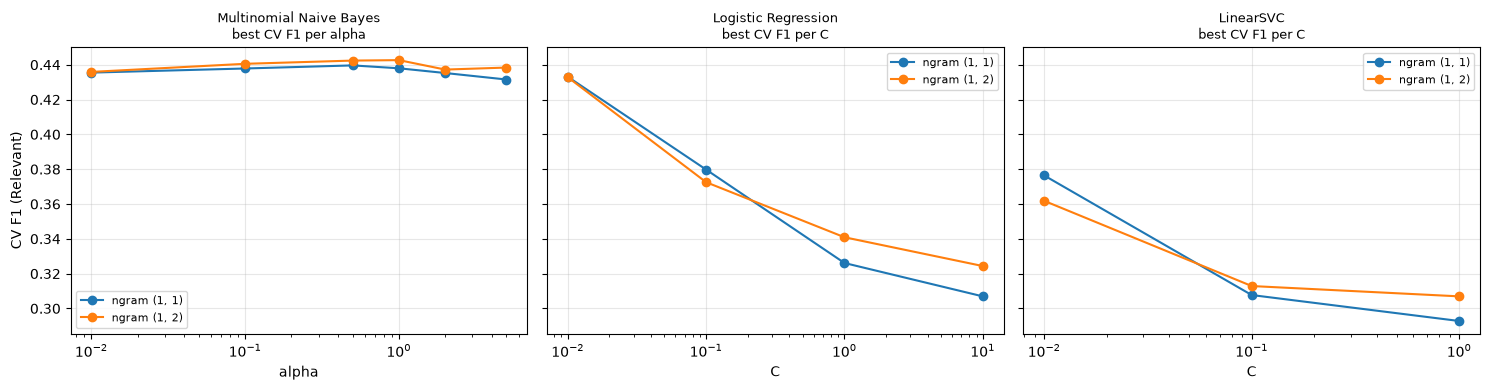

In [18]:
fig, axes = plt.subplots(1, len(searches), figsize=(5 * len(searches), 4), sharey=True)

for ax, (model_name, search) in zip(axes, searches.items()):
    cvres = pd.DataFrame(search.cv_results_)
    hyper = "param_clf__alpha" if "param_clf__alpha" in cvres else "param_clf__C"
    for ngram, grp in cvres.groupby("param_vec__ngram_range"):
        # best CV F1 at each hyperparameter value (max over max_features / class_weight)
        best_by_h = grp.groupby(hyper)["mean_test_score"].max()
        ax.plot(best_by_h.index.astype(float), best_by_h.values, marker="o", label=f"ngram {ngram}")
    ax.set_xscale("log")
    ax.set_xlabel(hyper.replace("param_clf__", ""))
    ax.set_title(f"{model_name}\nbest CV F1 per {hyper.replace('param_clf__', '')}", fontsize=9)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel("CV F1 (Relevant)")
plt.tight_layout()
plt.show()

### 8b.3 Best tuned configuration vs the best baseline

8b best: Logistic Regression @ 40000 feats (tuned)
{'C': 0.01, 'class_weight': 'balanced', 'max_features': 40000, 'ngram_range': (1, 1)}
vs baseline: Multinomial Naive Bayes @ 5000 feats (unigram)
Metric          Baseline    This run         Δ
Accuracy          0.7031      0.7444   +0.0413
Precision         0.3333      0.3602   +0.0269
Recall            0.6725      0.5669   -0.1056
F1-Score          0.4457      0.4405   -0.0052

Confusion matrix (baseline)      Confusion matrix (this run)
[[  934   382]            [[ 1030   286]
 [   93   191]]            [  123   161]]

CV F1 0.4331  →  test F1 0.4405   (gap +0.0074; a small gap means the CV estimate generalised)


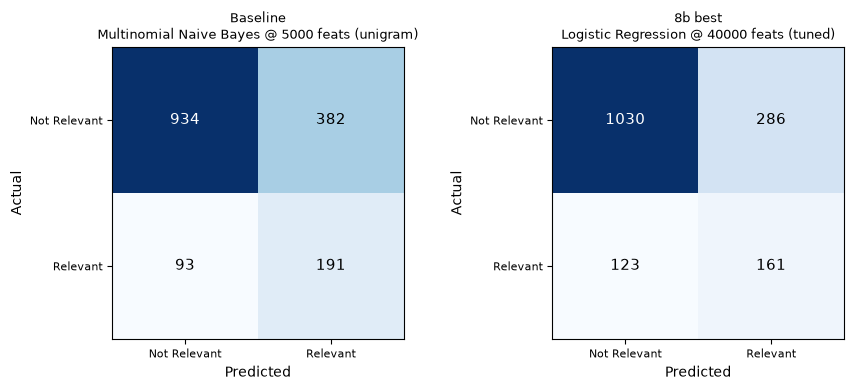

In [19]:
best_8b = grid_results.loc[grid_results["F1-Score"].idxmax()]
BEST_8B_NAME = f"{best_8b['Model']} @ {int(best_8b['Max Features'])} feats (tuned)"

print_comparison(best_8b, f"8b best: {BEST_8B_NAME}\n{best_8b['Best Params']}\nvs baseline: {BASELINE_NAME}")
print(f"CV F1 {best_8b['CV F1']:.4f}  →  test F1 {best_8b['F1-Score']:.4f}   "
      f"(gap {best_8b['F1-Score'] - best_8b['CV F1']:+.4f}; a small gap means the CV estimate generalised)")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_cm(axes[0], baseline, f"Baseline\n{BASELINE_NAME}")
plot_cm(axes[1], best_8b, f"8b best\n{BEST_8B_NAME}")
plt.tight_layout()
plt.show()

---
# Summary — baseline vs 8a vs 8b

In [20]:
baseline_row = baseline.to_dict()
baseline_row["Experiment"] = "Baseline (Member 7)"

summary = pd.DataFrame([baseline_row, best_8a.to_dict(), best_8b.to_dict()])
summary = summary[["Experiment", "Model", "Max Features"] + METRIC_COLS + CM_COLS]
summary = delta_vs_baseline(summary)
display(summary.round(4))

,Experiment,Model,Max Features,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP,Δ Accuracy,Δ Precision,Δ Recall,Δ F1-Score
0,Baseline (Member 7),Multinomial Naive Bayes,5000,0.7031,0.3333,0.6725,0.4457,934,382,93,191,0.0000,0.0000,0.0000,0.0000
1,8a: unigram+bigram,Multinomial Naive Bayes,5000,0.7081,0.3357,0.6585,0.4447,946,370,97,187,0.0050,0.0024,-0.0140,-0.0010
2,8b: GridSearchCV,Logistic Regression,40000,0.7444,0.3602,0.5669,0.4405,1030,286,123,161,0.0413,0.0269,-0.1056,-0.0052


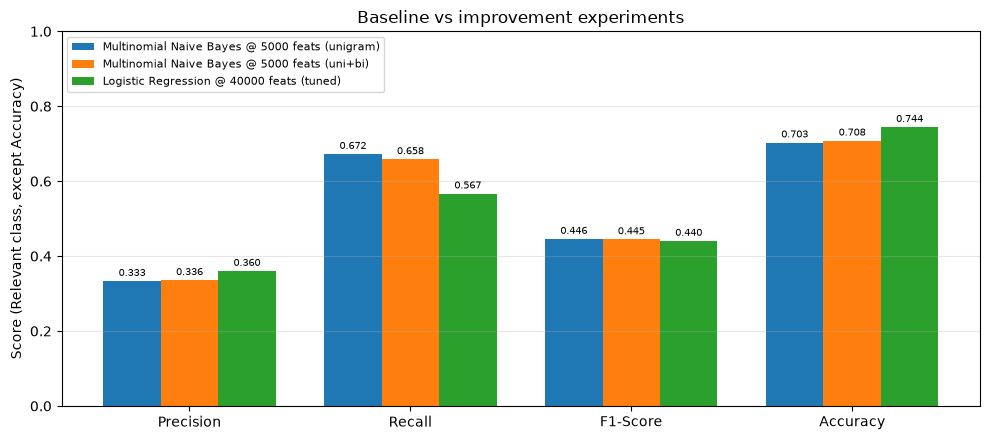

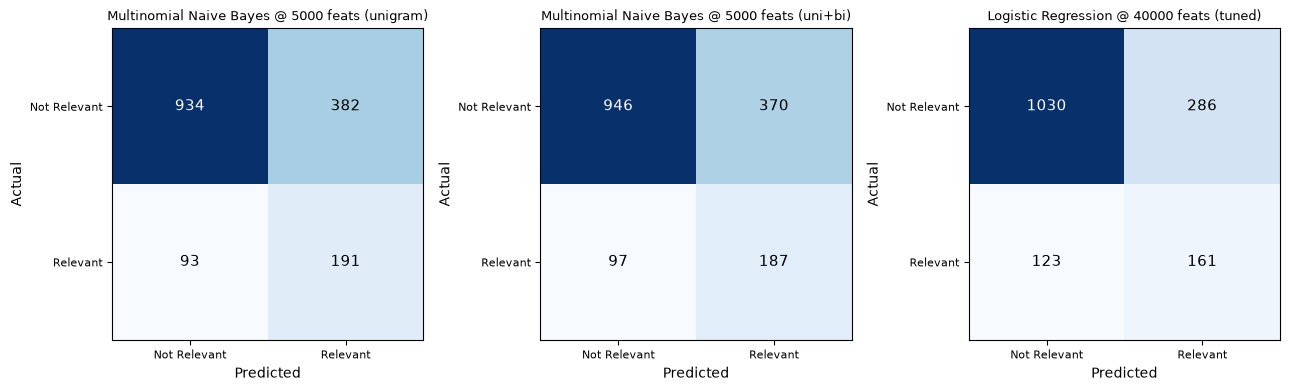

In [21]:
labels = [BASELINE_NAME, BEST_8A_NAME, BEST_8B_NAME]
metrics_to_plot = ["Precision", "Recall", "F1-Score", "Accuracy"]
x = np.arange(len(metrics_to_plot))
width = 0.26

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, (_, row) in enumerate(summary.iterrows()):
    vals = [row[m] for m in metrics_to_plot]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=labels[i])
    ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=2)
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1)
ax.set_ylabel("Score (Relevant class, except Accuracy)")
ax.set_title("Baseline vs improvement experiments")
ax.legend(fontsize=8, loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (_, row), title in zip(axes, summary.iterrows(), labels):
    plot_cm(ax, row, title)
plt.tight_layout()
plt.show()

## Save results for Member 9

In [22]:
all_improvement_runs = pd.concat([bigram_results, grid_results], ignore_index=True)
all_improvement_runs = all_improvement_runs[
    ["Experiment", "Model", "Max Features"] + METRIC_COLS + CM_COLS + ["CV F1", "Best Params"]
]
all_improvement_runs.round(4).to_csv("improvement_results.csv", index=False)
summary.round(4).to_csv("improvement_summary.csv", index=False)

print("Saved: improvement_results.csv   (every 8a and 8b run, same columns as model_comparison_results.csv + Experiment)")
print("Saved: improvement_summary.csv   (baseline vs best 8a vs best 8b, with Δ columns)")
display(all_improvement_runs.round(4))

Saved: improvement_results.csv   (every 8a and 8b run, same columns as model_comparison_results.csv + Experiment)
Saved: improvement_summary.csv   (baseline vs best 8a vs best 8b, with Δ columns)


,Experiment,Model,Max Features,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP,CV F1,Best Params
0,8a: unigram+bigram,Multinomial Naive Bayes,40000,0.7512,0.3656,0.5458,0.4379,1047,269,129,155,NaN,NaN
1,8a: unigram+bigram,Logistic Regression,40000,0.7944,0.3743,0.2359,0.2894,1204,112,217,67,NaN,NaN
2,8a: unigram+bigram,LinearSVC,40000,0.7775,0.3462,0.2852,0.3127,1163,153,203,81,NaN,NaN
3,8a: unigram+bigram,LinearSVC (Balanced),40000,0.7750,0.3417,0.2887,0.3130,1158,158,202,82,NaN,NaN
4,8a: unigram+bigram,Multinomial Naive Bayes,5000,0.7081,0.3357,0.6585,0.4447,946,370,97,187,NaN,NaN
5,8a: unigram+bigram,Logistic Regression,5000,0.7638,0.3259,0.3099,0.3177,1134,182,196,88,NaN,NaN
6,8a: unigram+bigram,LinearSVC,5000,0.7306,0.2882,0.3521,0.3170,1069,247,184,100,NaN,NaN
7,8a: unigram+bigram,LinearSVC (Balanced),5000,0.7294,0.2913,0.3662,0.3245,1063,253,180,104,NaN,NaN
8,8a: unigram+bigram,Multinomial Naive Bayes,1000,0.7038,0.3241,0.6162,0.4248,951,365,109,175,NaN,NaN
9,8a: unigram+bigram,Logistic Regression,1000,0.7938,0.3693,0.2289,0.2826,1205,111,219,65,NaN,NaN


## Analysis

**8a — bigrams.**
- Change vs baseline (P / R / F1 / accuracy): the best 8a configuration (Multinomial NB, unigram+bigram, 5,000 features) scores Accuracy 0.7081, Precision 0.3357, Recall 0.6585, F1 0.4447 — essentially a tie with the baseline (Accuracy 0.7031, Precision 0.3333, Recall 0.6725, F1 0.4457): ΔAccuracy +0.0050, ΔPrecision +0.0024, ΔRecall −0.0140, ΔF1 −0.0010. Adding bigrams at this feature size neither helps nor hurts in any meaningful way.
- Which classifier benefited most, and at which feature size: Multinomial Naive Bayes at 40,000 features, which gained +0.0599 recall and +0.0126 F1 over its own unigram-only run (see the per-model delta table above). Every other model/feature-size combination changed by less than ±0.02 F1, and several (Logistic Regression and LinearSVC at 40,000 and 5,000 features) actually lost recall and F1 when bigrams were added.
- Why 1,000 features barely changes (bigram share of the vocabulary at each cap — see 8a.1): at `max_features=1000`, only 68 of the 1,000 vocabulary slots end up being bigrams (6.8%) because single common words are far more frequent than any specific two-word phrase, so they fill almost the entire budget first. With that few bigram features actually present, the model has almost no phrase-level signal to use, so results barely move from the unigram-only baseline at that size. At 40,000 features, by contrast, 61.6% of the vocabulary is bigrams — there's enough room for both, which is why the effect (positive or negative) is largest there.

**8b — GridSearchCV.**
- Best configuration and what CV selected (alpha / C / class_weight / ngram / max_features): the top result by test F1 was **Logistic Regression** with `C=0.01, class_weight="balanced", max_features=40000, ngram_range=(1,1)` (CV F1 0.4331 → test F1 0.4405). Naive Bayes selected `alpha=1.0, max_features=20000, ngram_range=(1,2)` (CV F1 0.4426 → test F1 0.4346), and LinearSVC selected `C=0.01, class_weight="balanced", max_features=20000, ngram_range=(1,1)` (CV F1 0.3764 → test F1 0.3890). Notably, two of the three tuned classifiers picked **20,000 features** — a value outside the original three-point sweep (40,000 / 5,000 / 1,000) — which suggests that sweep, while informative, was too coarse to land on the actual best vocabulary size for every model.
- Change vs baseline: the best 8b run (tuned Logistic Regression) scores Accuracy 0.7444, Precision 0.3602, Recall 0.5669, F1 0.4405 vs the baseline's Accuracy 0.7031, Precision 0.3333, Recall 0.6725, F1 0.4457 — ΔAccuracy +0.0413, ΔPrecision +0.0269, ΔRecall −0.1056, ΔF1 −0.0052. Tuning traded a large chunk of recall for a real gain in precision and accuracy, landing at essentially the same F1 as the baseline.
- CV F1 vs test F1 gap — did the tuned model generalise: yes. The gap between CV score and test score was small for all three tuned models (Logistic Regression +0.0074, LinearSVC +0.0126, Naive Bayes −0.0080) — none of them overfit to the cross-validation folds, so the CV estimates were a reliable guide to test performance.

**Overall.**
- Which experiment gives the best Relevant-class F1, and does it improve precision or recall (or both): the **baseline** (Multinomial NB, unigram, 5,000 features, F1 0.4457) still edges out both improvement experiments, which land within ~0.005 F1 of it but reach that score very differently. 8a's best run is almost a duplicate of the baseline (same model/feature size, bigrams added). 8b's best run (tuned Logistic Regression) sacrifices recall for precision and accuracy rather than improving everything at once — no experiment improves both precision and recall simultaneously over the baseline.
- Recommendation for Member 9's final table: report the Member 7 baseline (Multinomial NB @ 5,000 features) as the primary model — it still has the best F1 and by far the best recall (0.6725), which matters most for a "Relevant" class that's the minority and the one actually of interest. Note the tuned Logistic Regression from 8b (C=0.01, balanced, 40,000 features, unigram) as a viable alternative only if false positives are costlier than missed articles for the use case, since it trades ~0.11 recall for better precision/accuracy. Bigrams (8a) are not worth recommending on their own — the gains were inconsistent and never beat the baseline.